# VVV — Curvas de luz de 50 estrellas

Este notebook genera **las curvas de luz magnitud Ks vs tiempo de 50 estrellas VVV**.  
Produce tres tipos de salida:

1. Una figura general con las 50 curvas.
2. Figuras por páginas, 10 estrellas por página.
3. 50 figuras individuales, una por estrella.

Coloca el archivo `VVV_Sample.fits` en la misma carpeta del notebook antes de ejecutar.

In [1]:
# Instalar si hace falta, desde la terminal con .LABS activo:
# python -m pip install numpy matplotlib astropy

from pathlib import Path
from astropy.io import fits

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 120


def clean_lightcurve(t, mag, err=None, min_points=5):
    """Limpia tiempo, magnitud y error sin desalinearlos."""
    t = np.asarray(t, dtype=float).ravel()
    mag = np.asarray(mag, dtype=float).ravel()

    if err is None:
        err = np.full_like(mag, np.nan, dtype=float)
    else:
        err = np.asarray(err, dtype=float).ravel()

    n = min(len(t), len(mag), len(err))
    t, mag, err = t[:n], mag[:n], err[:n]

    mask = np.isfinite(t) & np.isfinite(mag)
    t, mag, err = t[mask], mag[mask], err[mask]

    if len(t) < min_points:
        return None, None, None

    order = np.argsort(t)
    t, mag, err = t[order], mag[order], err[order]

    if np.isfinite(err).sum() == 0:
        err = None
    else:
        err[~np.isfinite(err)] = np.nan
        err[err <= 0] = np.nan
        if np.isnan(err).all():
            err = None
        else:
            med = np.nanmedian(err)
            err = np.where(np.isnan(err), med, err)

    return t, mag, err


def plot_single_lightcurve(curve, outdir, prefix, time_label, mag_label):
    """Guarda una curva de luz individual."""
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    name = str(curve["name"]).replace("/", "_").replace("\\", "_").replace(" ", "_")
    t, mag, err = curve["time"], curve["mag"], curve.get("err")

    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    if err is not None:
        ax.errorbar(t, mag, yerr=err, fmt=".", markersize=4, capsize=1.5, alpha=0.85)
    else:
        ax.scatter(t, mag, s=8, alpha=0.85)

    ax.invert_yaxis()
    ax.set_xlabel(time_label)
    ax.set_ylabel(mag_label)
    ax.set_title(f"{prefix} | {curve['name']}")
    ax.grid(alpha=0.3)
    fig.tight_layout()

    path = outdir / f"{prefix}_{name}_curva_luz.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return path


def plot_lightcurve_pages(curves, outdir, prefix, time_label, mag_label, per_page=10, ncols=2):
    """Guarda páginas con varias curvas de luz hasta cubrir las 50 estrellas."""
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    saved = []
    nrows = int(np.ceil(per_page / ncols))

    for start in range(0, len(curves), per_page):
        subset = curves[start:start + per_page]
        fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows))
        axes = np.ravel(axes)

        for ax, curve in zip(axes, subset):
            t, mag, err = curve["time"], curve["mag"], curve.get("err")

            if err is not None:
                ax.errorbar(t, mag, yerr=err, fmt=".", markersize=3, capsize=1, alpha=0.8)
            else:
                ax.scatter(t, mag, s=6, alpha=0.8)

            ax.invert_yaxis()
            ax.set_xlabel(time_label)
            ax.set_ylabel(mag_label)
            ax.set_title(str(curve["name"]), fontsize=9)
            ax.grid(alpha=0.25)

        for ax in axes[len(subset):]:
            ax.axis("off")

        page = start // per_page + 1
        fig.suptitle(f"{prefix}: curvas de luz {start + 1}--{start + len(subset)} de {len(curves)}", fontsize=14)
        fig.tight_layout()

        path = outdir / f"{prefix}_curvas_luz_pagina_{page:02d}.png"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        saved.append(path)

    return saved


def plot_lightcurve_grid_50(curves, outdir, prefix, time_label, mag_label):
    """Guarda una figura resumen con las 50 curvas en una sola imagen."""
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    n = len(curves)
    ncols = 5
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 2.6 * nrows))
    axes = np.ravel(axes)

    for ax, curve in zip(axes, curves):
        t, mag, err = curve["time"], curve["mag"], curve.get("err")

        if err is not None:
            ax.errorbar(t, mag, yerr=err, fmt=".", markersize=2.5, capsize=0.7, alpha=0.75)
        else:
            ax.scatter(t, mag, s=5, alpha=0.75)

        ax.invert_yaxis()
        ax.set_title(str(curve["name"]), fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2)

    for ax in axes[n:]:
        ax.axis("off")

    fig.supxlabel(time_label)
    fig.supylabel(mag_label)
    fig.suptitle(f"{prefix}: curvas de luz de las {n} estrellas", fontsize=16)
    fig.tight_layout()

    path = outdir / f"{prefix}_50_curvas_luz_grid.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return path


In [3]:
# =========================
# CONFIGURACIÓN VVV
# =========================

FITS_PATH = Path("VVV_Sample.fits")
OUTDIR = Path("resultados_VVV_50_curvas")
OUTDIR.mkdir(exist_ok=True)

N_ESTRELLAS = 50
TIME_LABEL = "Tiempo (MJD)"
MAG_LABEL = "Magnitud Ks"

print("Archivo esperado:", FITS_PATH.resolve())

Archivo esperado: C:\Users\Petya_\MEGAPROJECTS\EDGESCAN_SIGHT1\HR_DE_MI_BEBE\VVV_Sample.fits


In [4]:
# =========================
# CARGA DEL ARCHIVO FITS VVV
# =========================

if not FITS_PATH.exists():
    raise FileNotFoundError(
        f"No encontré {FITS_PATH}. Pon el archivo FITS en la misma carpeta del notebook."
    )

VVV_data = fits.open(FITS_PATH)
VVV_data.info()

# Estructura usada en el notebook original:
# b278: ID=1, Ks=2, Ks_err=5, Ks_mjd=8
# b279: ID=11, Ks=12, Ks_err=15, Ks_mjd=18
Id_b278, Id_b279 = VVV_data[1].data, VVV_data[11].data
Ks_b278, Ks_b279 = VVV_data[2].data, VVV_data[12].data
Ks_err_b278, Ks_err_b279 = VVV_data[5].data, VVV_data[15].data
Ks_mjd_b278, Ks_mjd_b279 = VVV_data[8].data, VVV_data[18].data

Filename: VVV_Sample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   ()      
  1  ID_B278       1 ImageHDU         7   (304,)   int64   
  2  KS_B278       1 ImageHDU         8   (523, 304)   float64   
  3  H_B278        1 ImageHDU         8   (32, 304)   float64   
  4  J_B278        1 ImageHDU         8   (25, 304)   float64   
  5  KS_ERR_B278    1 ImageHDU         8   (523, 304)   float64   
  6  H_ERR_B278    1 ImageHDU         8   (32, 304)   float64   
  7  J_ERR_B278    1 ImageHDU         8   (25, 304)   float64   
  8  KS_MJD_B278    1 ImageHDU         8   (523, 304)   float64   
  9  H_MJD_B278    1 ImageHDU         8   (32, 304)   float64   
 10  J_MJD_B278    1 ImageHDU         8   (25, 304)   float64   
 11  ID_B279       1 ImageHDU         7   (286,)   int64   
 12  KS_B279       1 ImageHDU         8   (960, 286)   float64   
 13  H_B279        1 ImageHDU         8   (14, 286)   float64   
 14  J_B279        1

In [5]:
# =========================
# EXTRACCIÓN DE CURVAS VVV
# =========================

def stringify_id(x, fallback):
    """Convierte el ID del FITS a texto de forma robusta."""
    try:
        arr = np.asarray(x).ravel()
        if len(arr) == 0:
            return str(fallback)
        value = arr[0]
    except Exception:
        value = x

    if isinstance(value, bytes):
        return value.decode(errors="ignore")

    try:
        if np.isfinite(value) and float(value).is_integer():
            return str(int(value))
    except Exception:
        pass

    return str(value)


def extract_vvv_lightcurves(id_arr, mag_arr, err_arr, mjd_arr, field_label):
    curves = []
    n_sources = min(len(id_arr), len(mag_arr), len(err_arr), len(mjd_arr))

    for i in range(n_sources):
        star_id = stringify_id(id_arr[i], fallback=i)
        name = f"{field_label}_{star_id}"

        t, mag, err = clean_lightcurve(mjd_arr[i], mag_arr[i], err_arr[i])
        if t is None:
            continue

        curves.append({
            "name": name,
            "time": t,
            "mag": mag,
            "err": err,
            "field": field_label,
        })

    return curves

vvv_all = []
vvv_all.extend(extract_vvv_lightcurves(Id_b278, Ks_b278, Ks_err_b278, Ks_mjd_b278, "b278"))
vvv_all.extend(extract_vvv_lightcurves(Id_b279, Ks_b279, Ks_err_b279, Ks_mjd_b279, "b279"))

print("Curvas VVV válidas disponibles:", len(vvv_all))

vvv_curves = vvv_all[:N_ESTRELLAS]
print(f"Curvas de luz seleccionadas: {len(vvv_curves)}")

if len(vvv_curves) < N_ESTRELLAS:
    print(f"Advertencia: se pidieron {N_ESTRELLAS}, pero solo se pudieron cargar {len(vvv_curves)} curvas válidas.")

Curvas VVV válidas disponibles: 590
Curvas de luz seleccionadas: 50


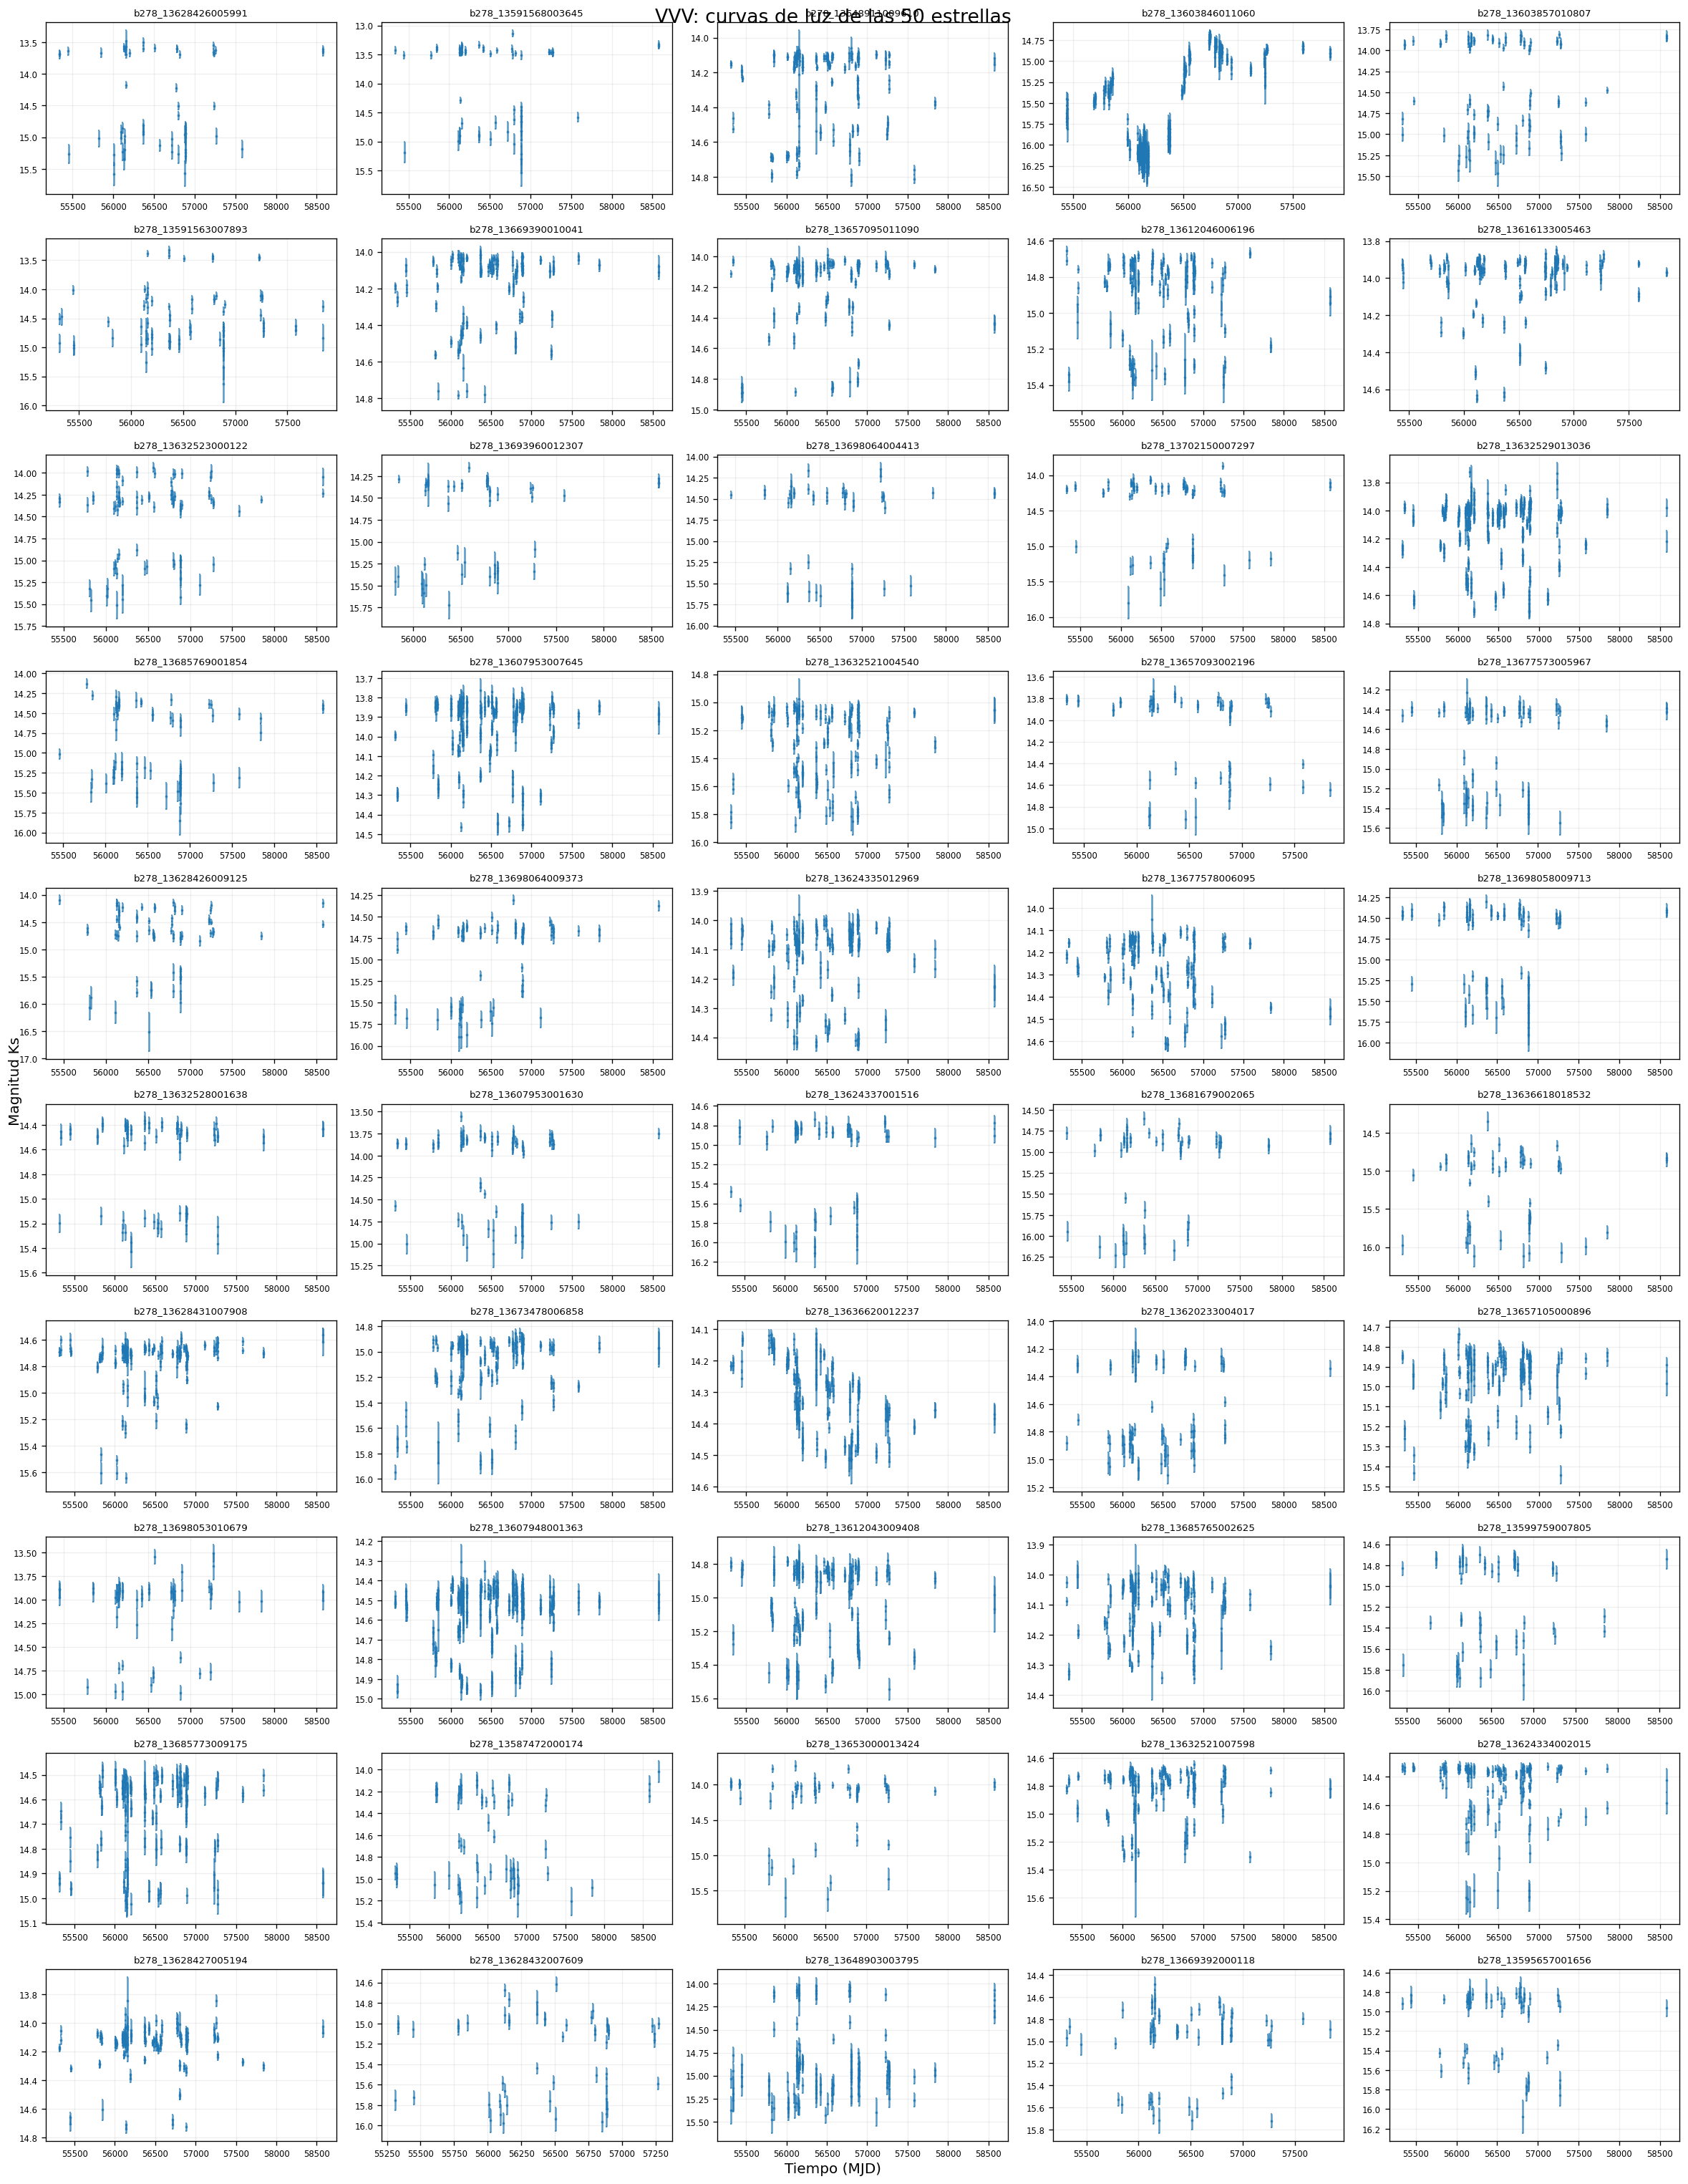

Figura general guardada en: resultados_VVV_50_curvas\VVV_50_curvas_luz_grid.png


In [6]:
# =========================
# FIGURA GENERAL: LAS 50 CURVAS EN UNA SOLA IMAGEN
# =========================

grid_path = plot_lightcurve_grid_50(
    vvv_curves,
    outdir=OUTDIR,
    prefix="VVV",
    time_label=TIME_LABEL,
    mag_label=MAG_LABEL,
)

print("Figura general guardada en:", grid_path)

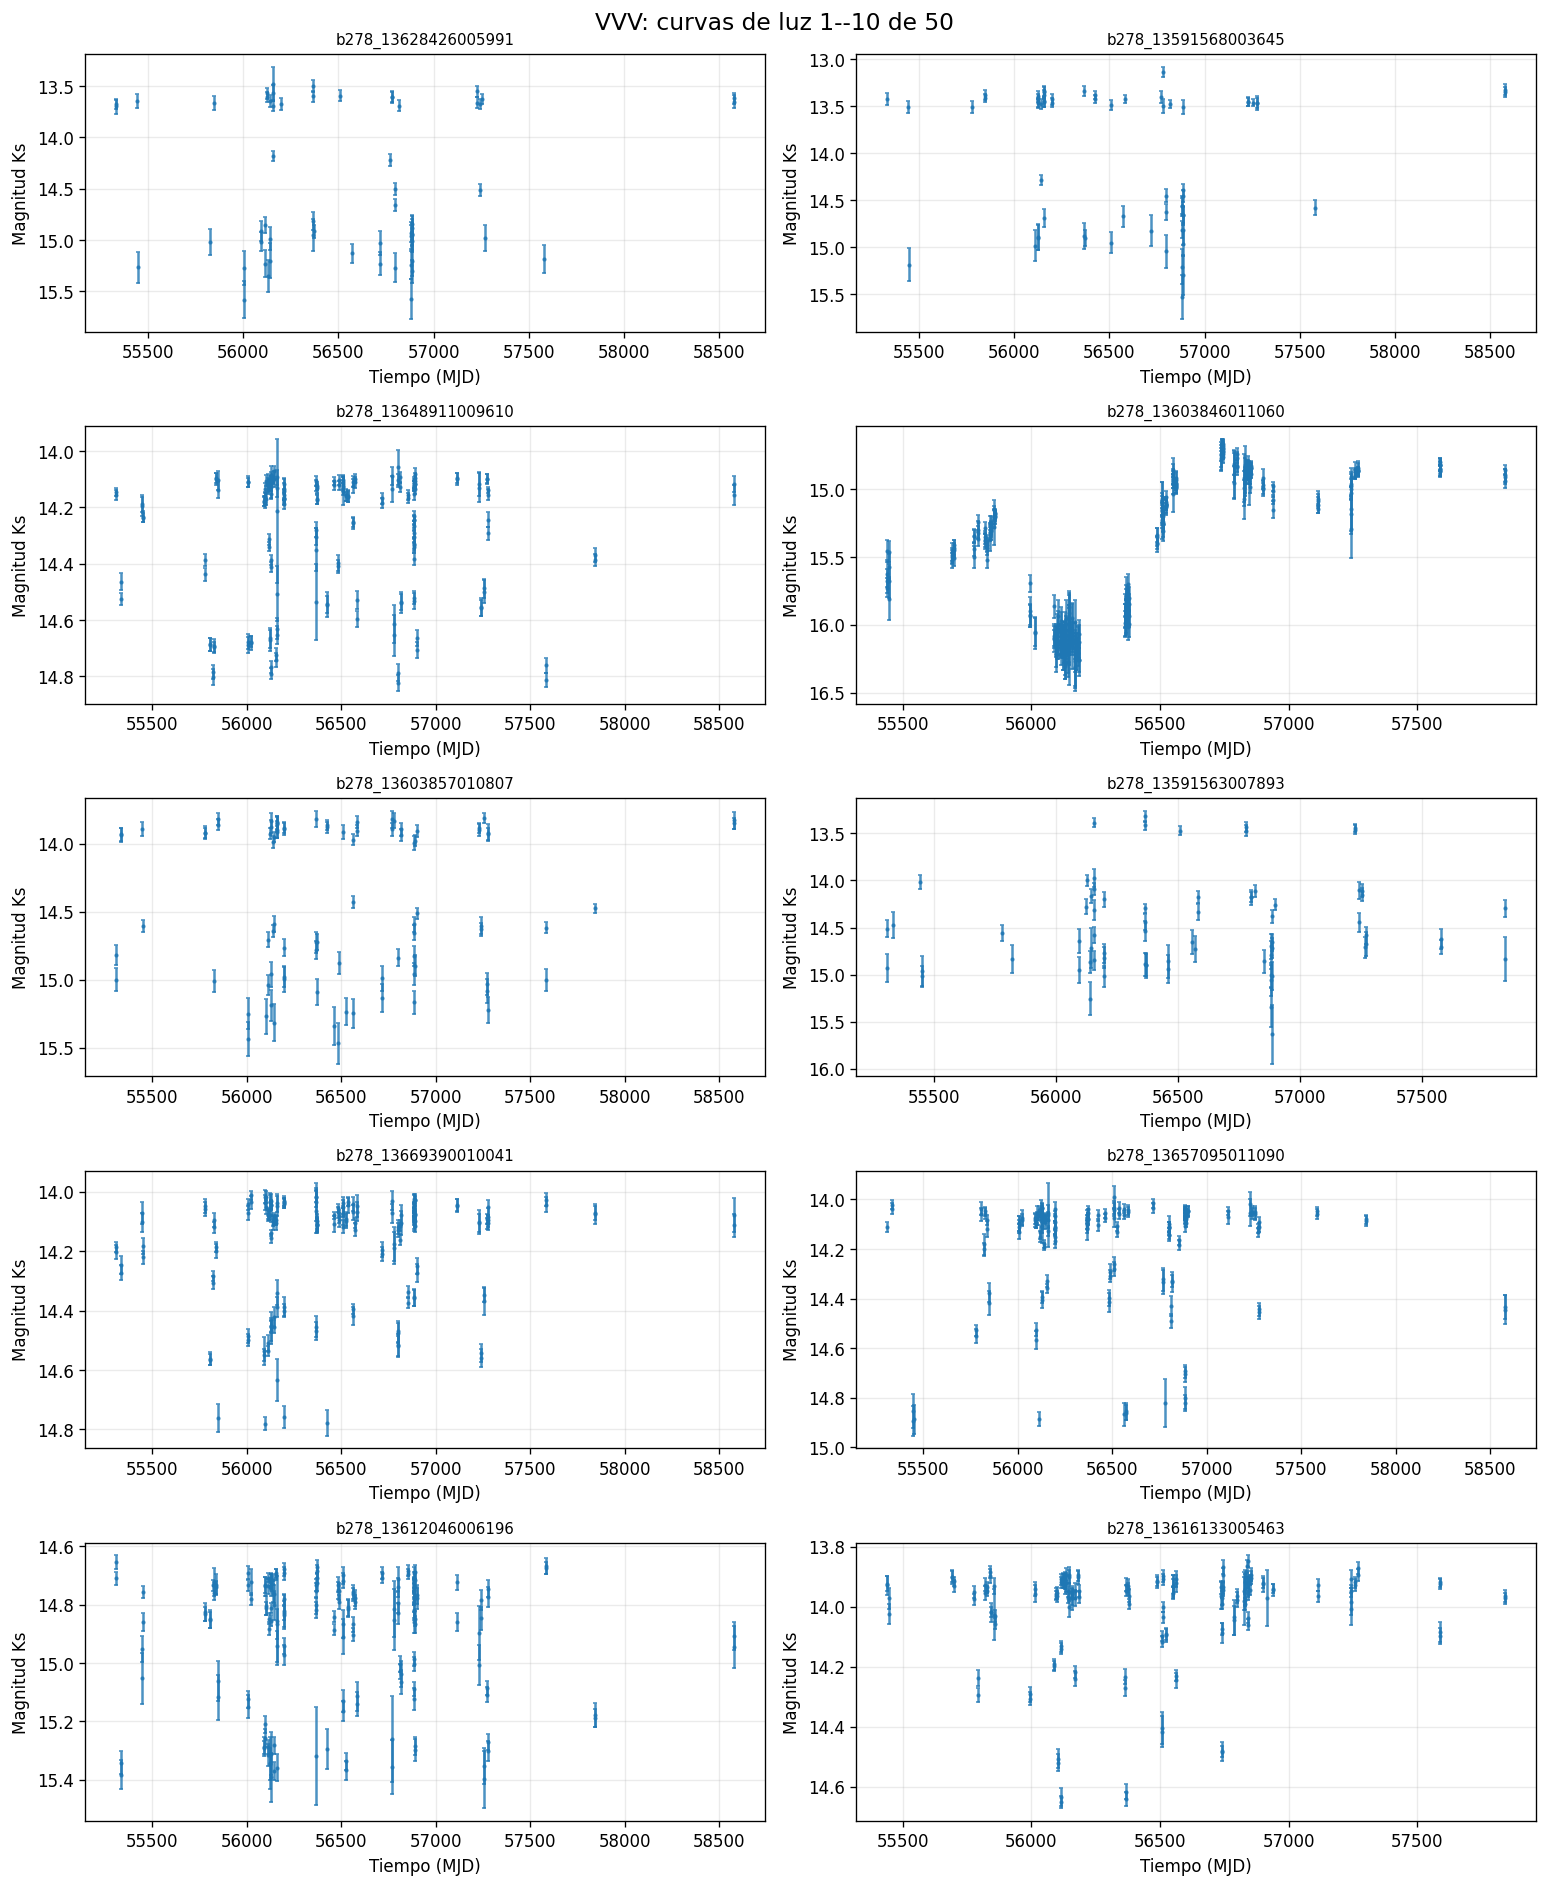

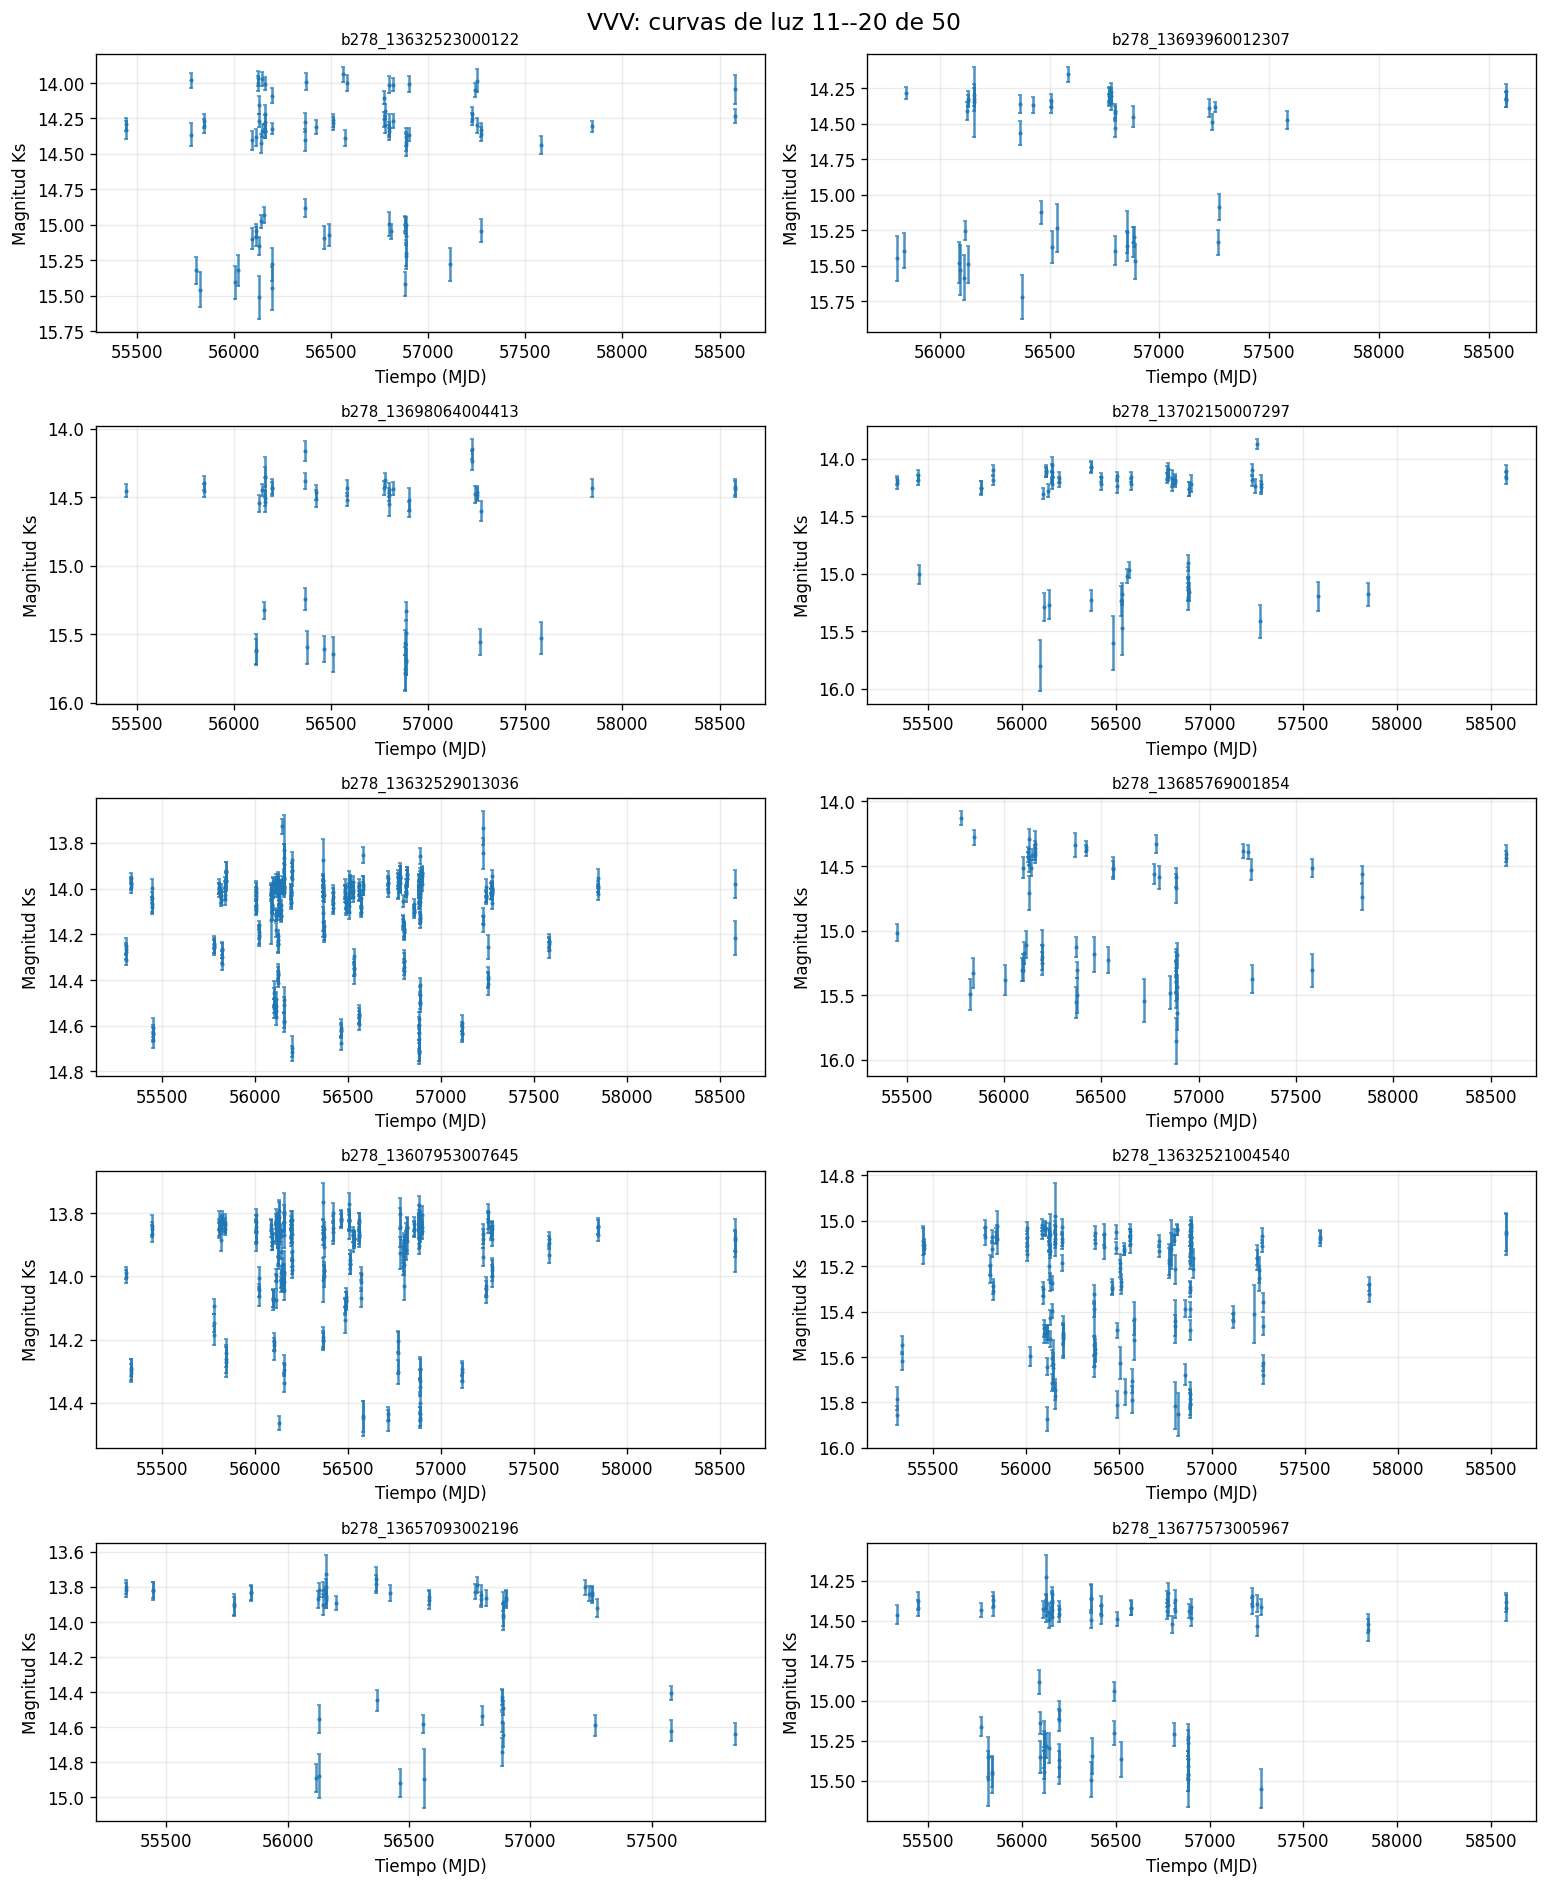

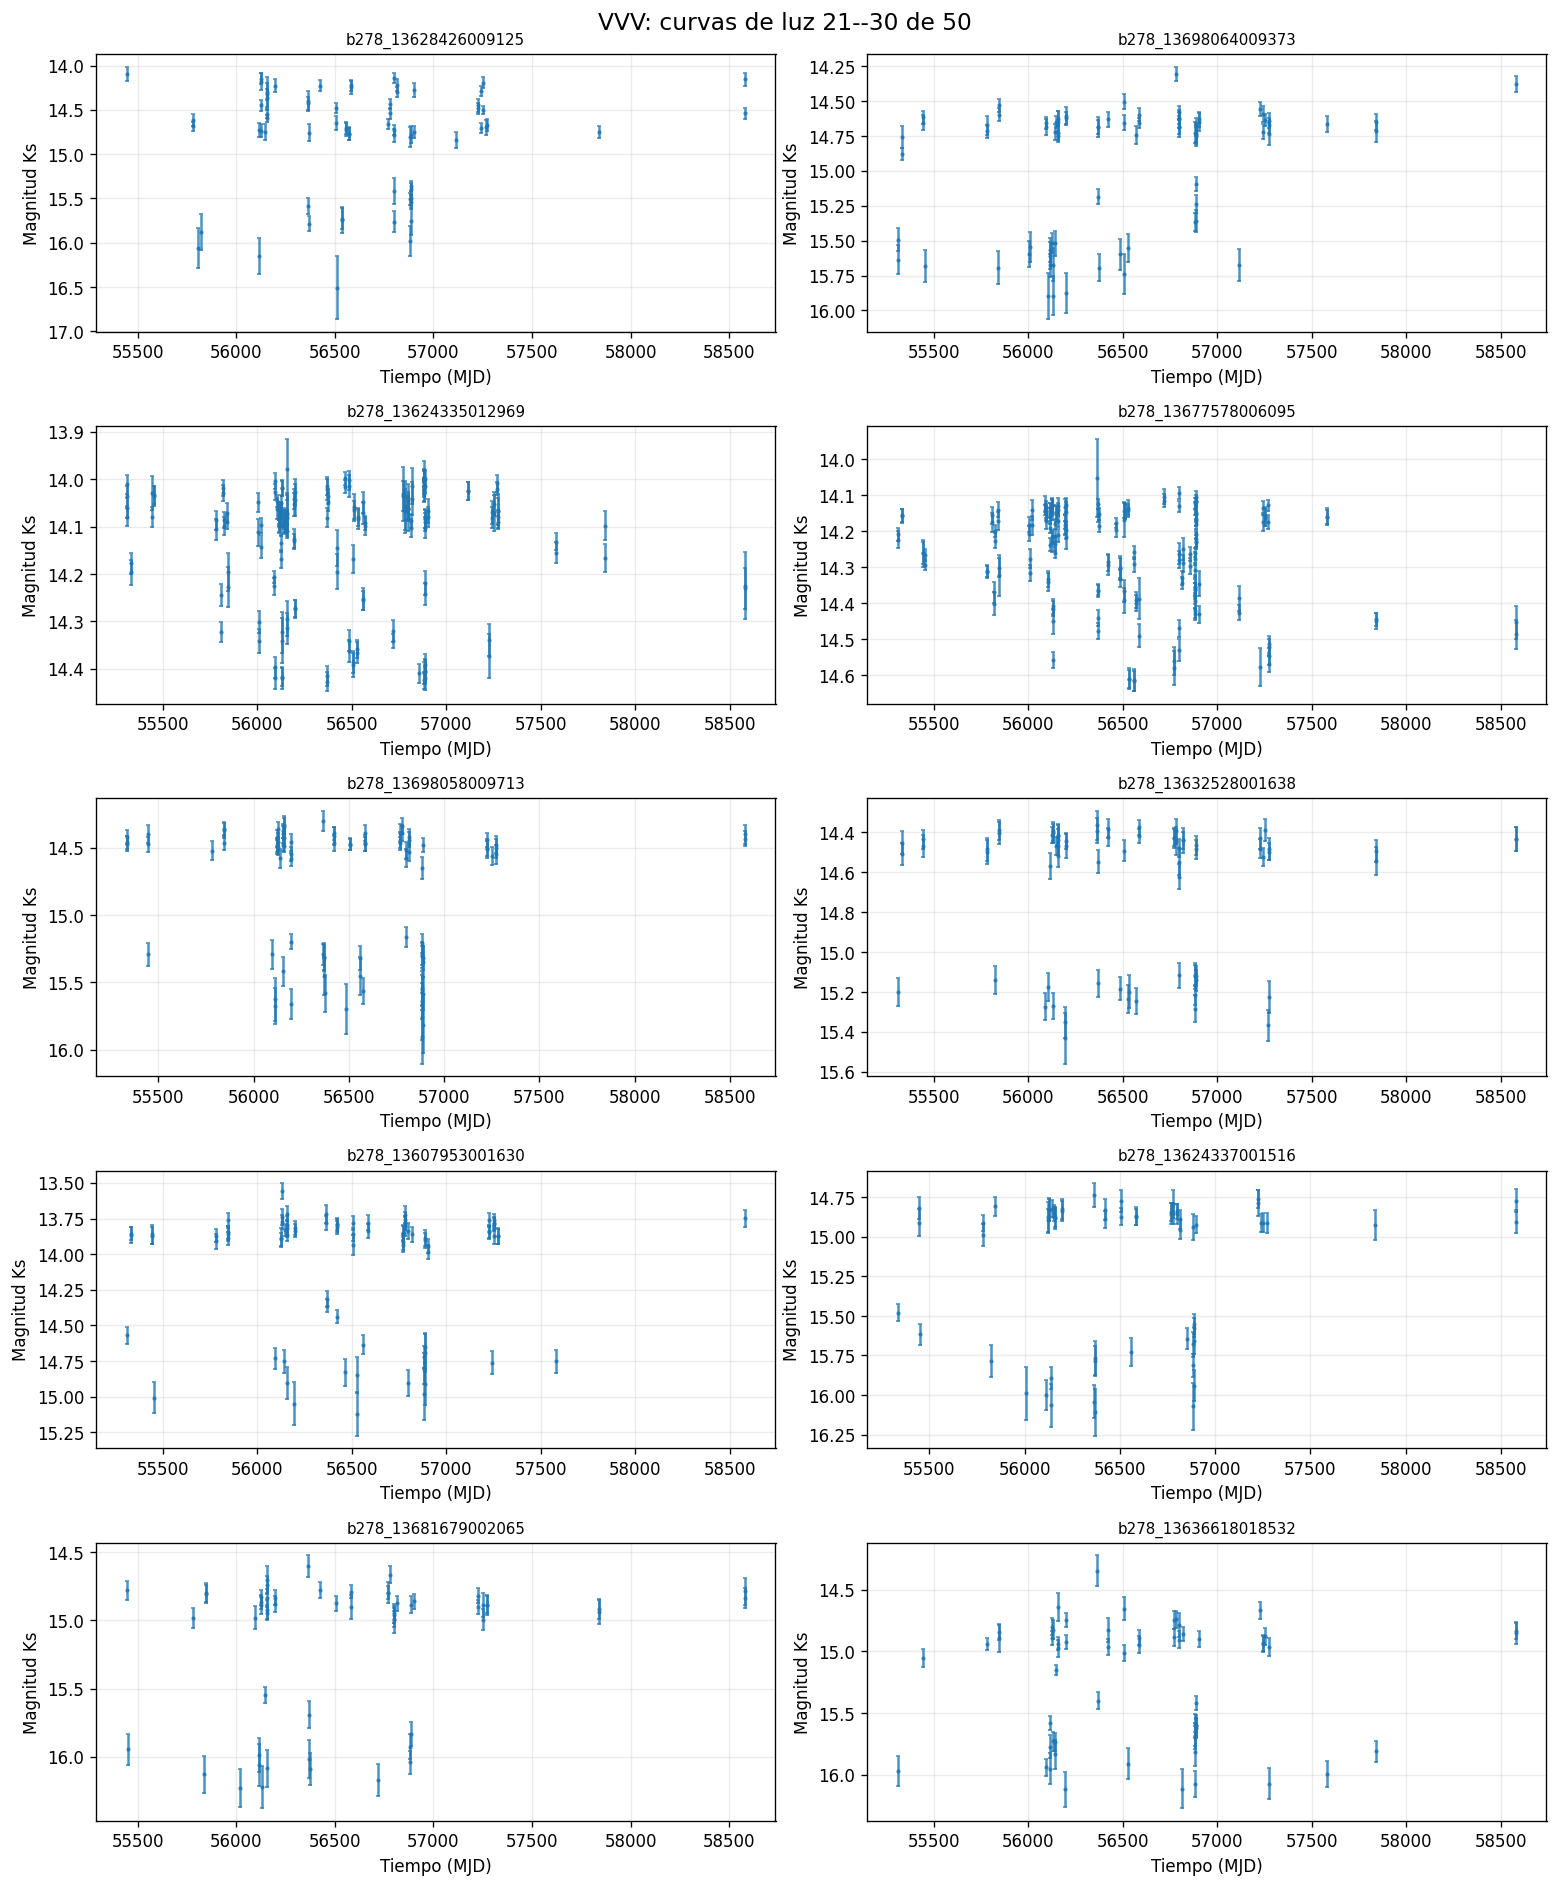

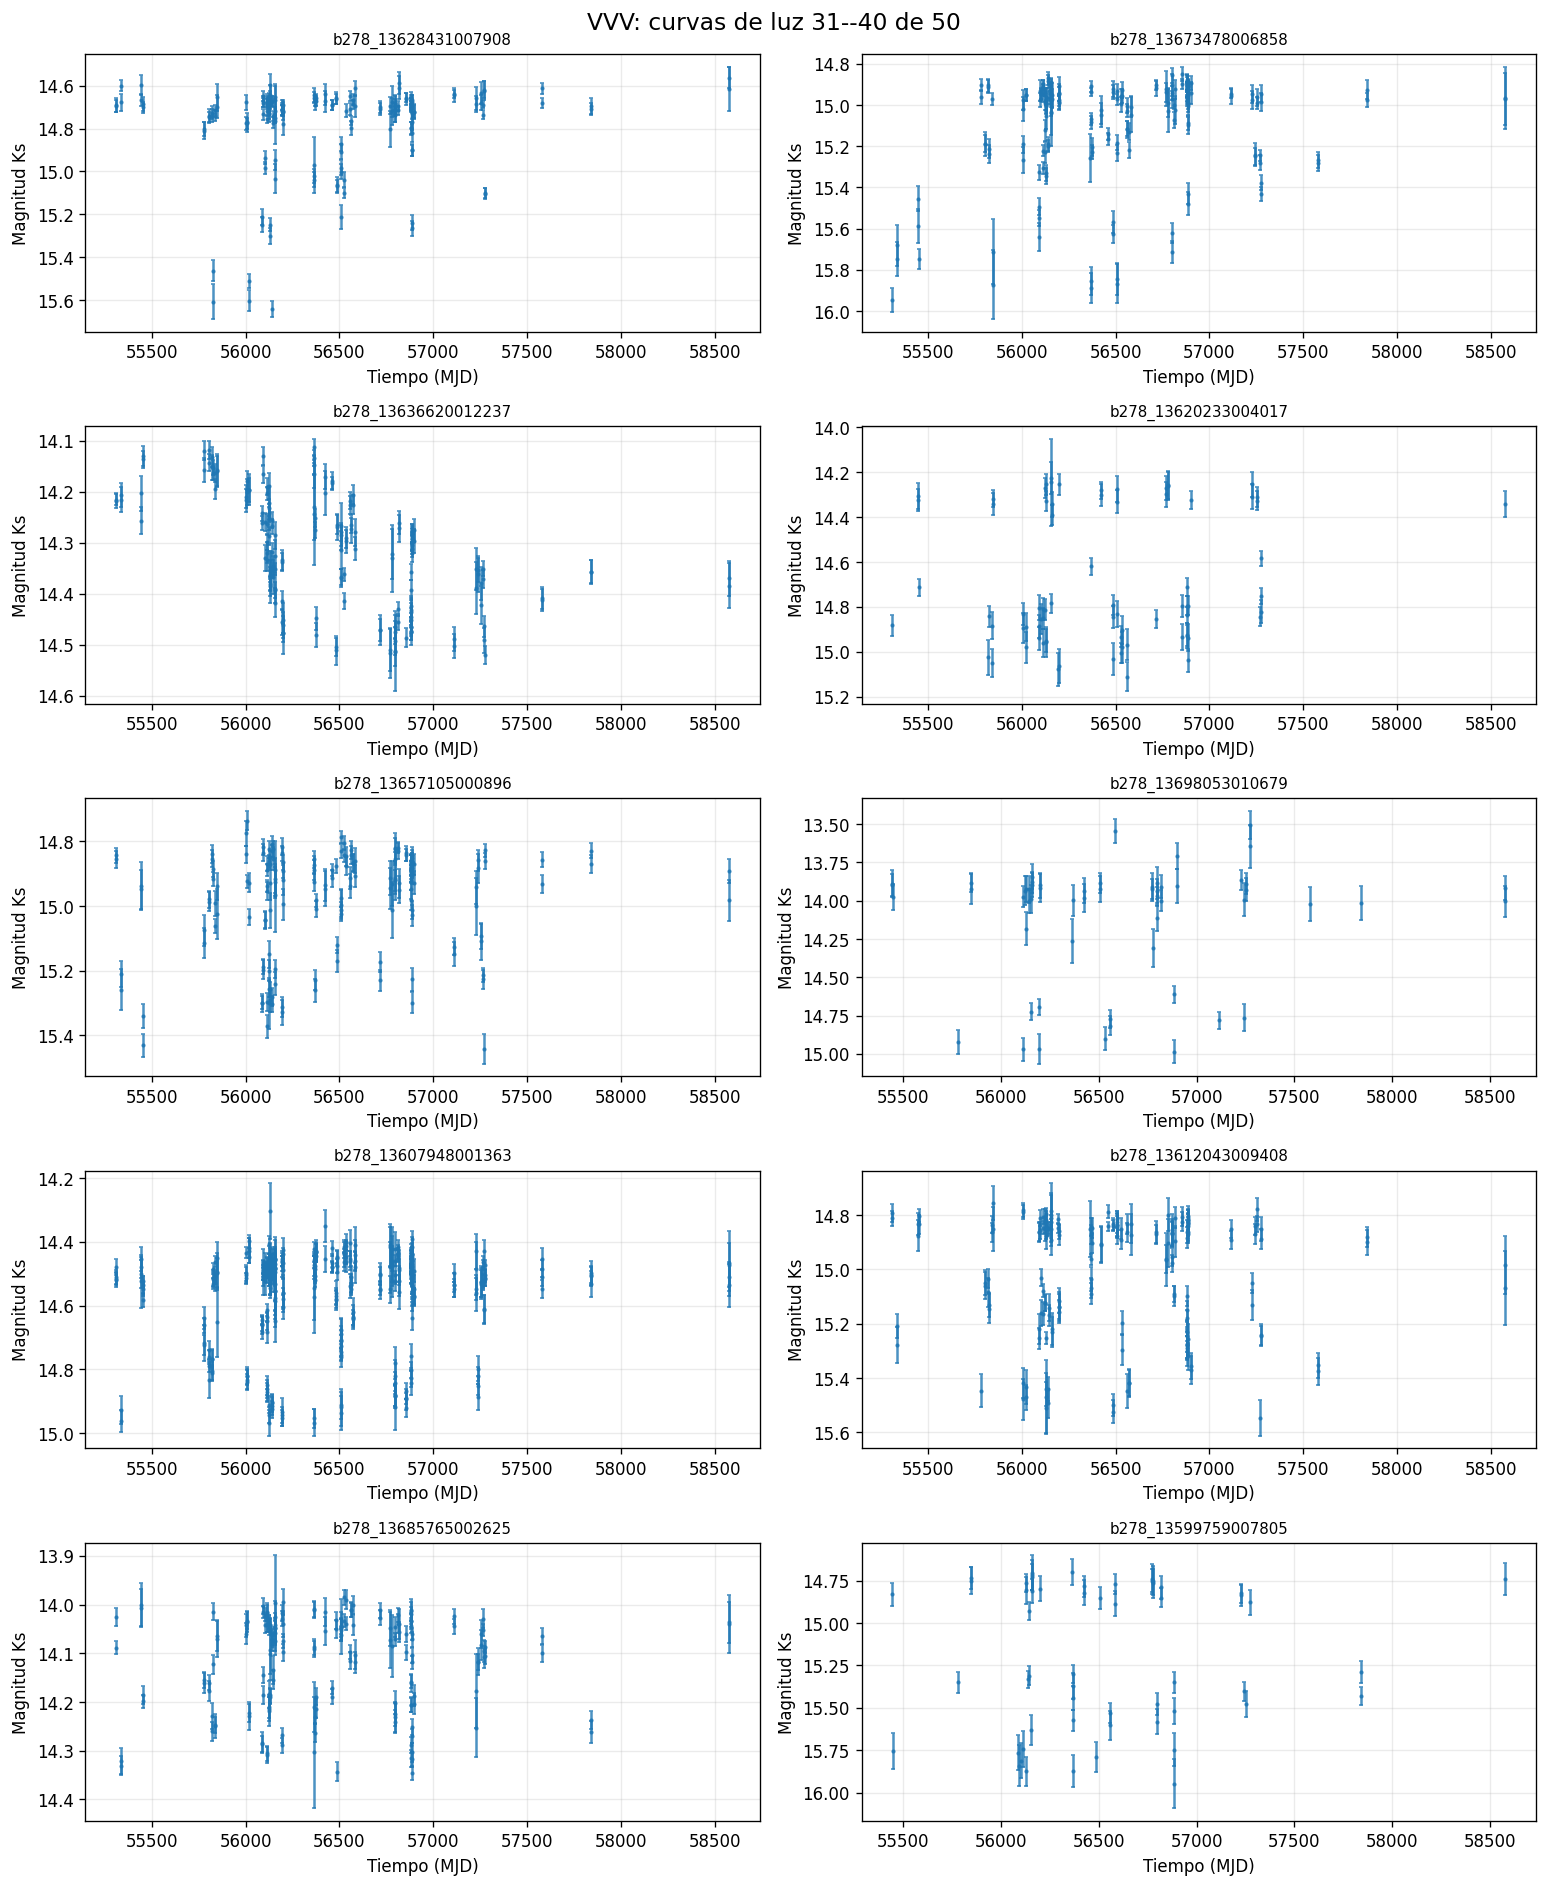

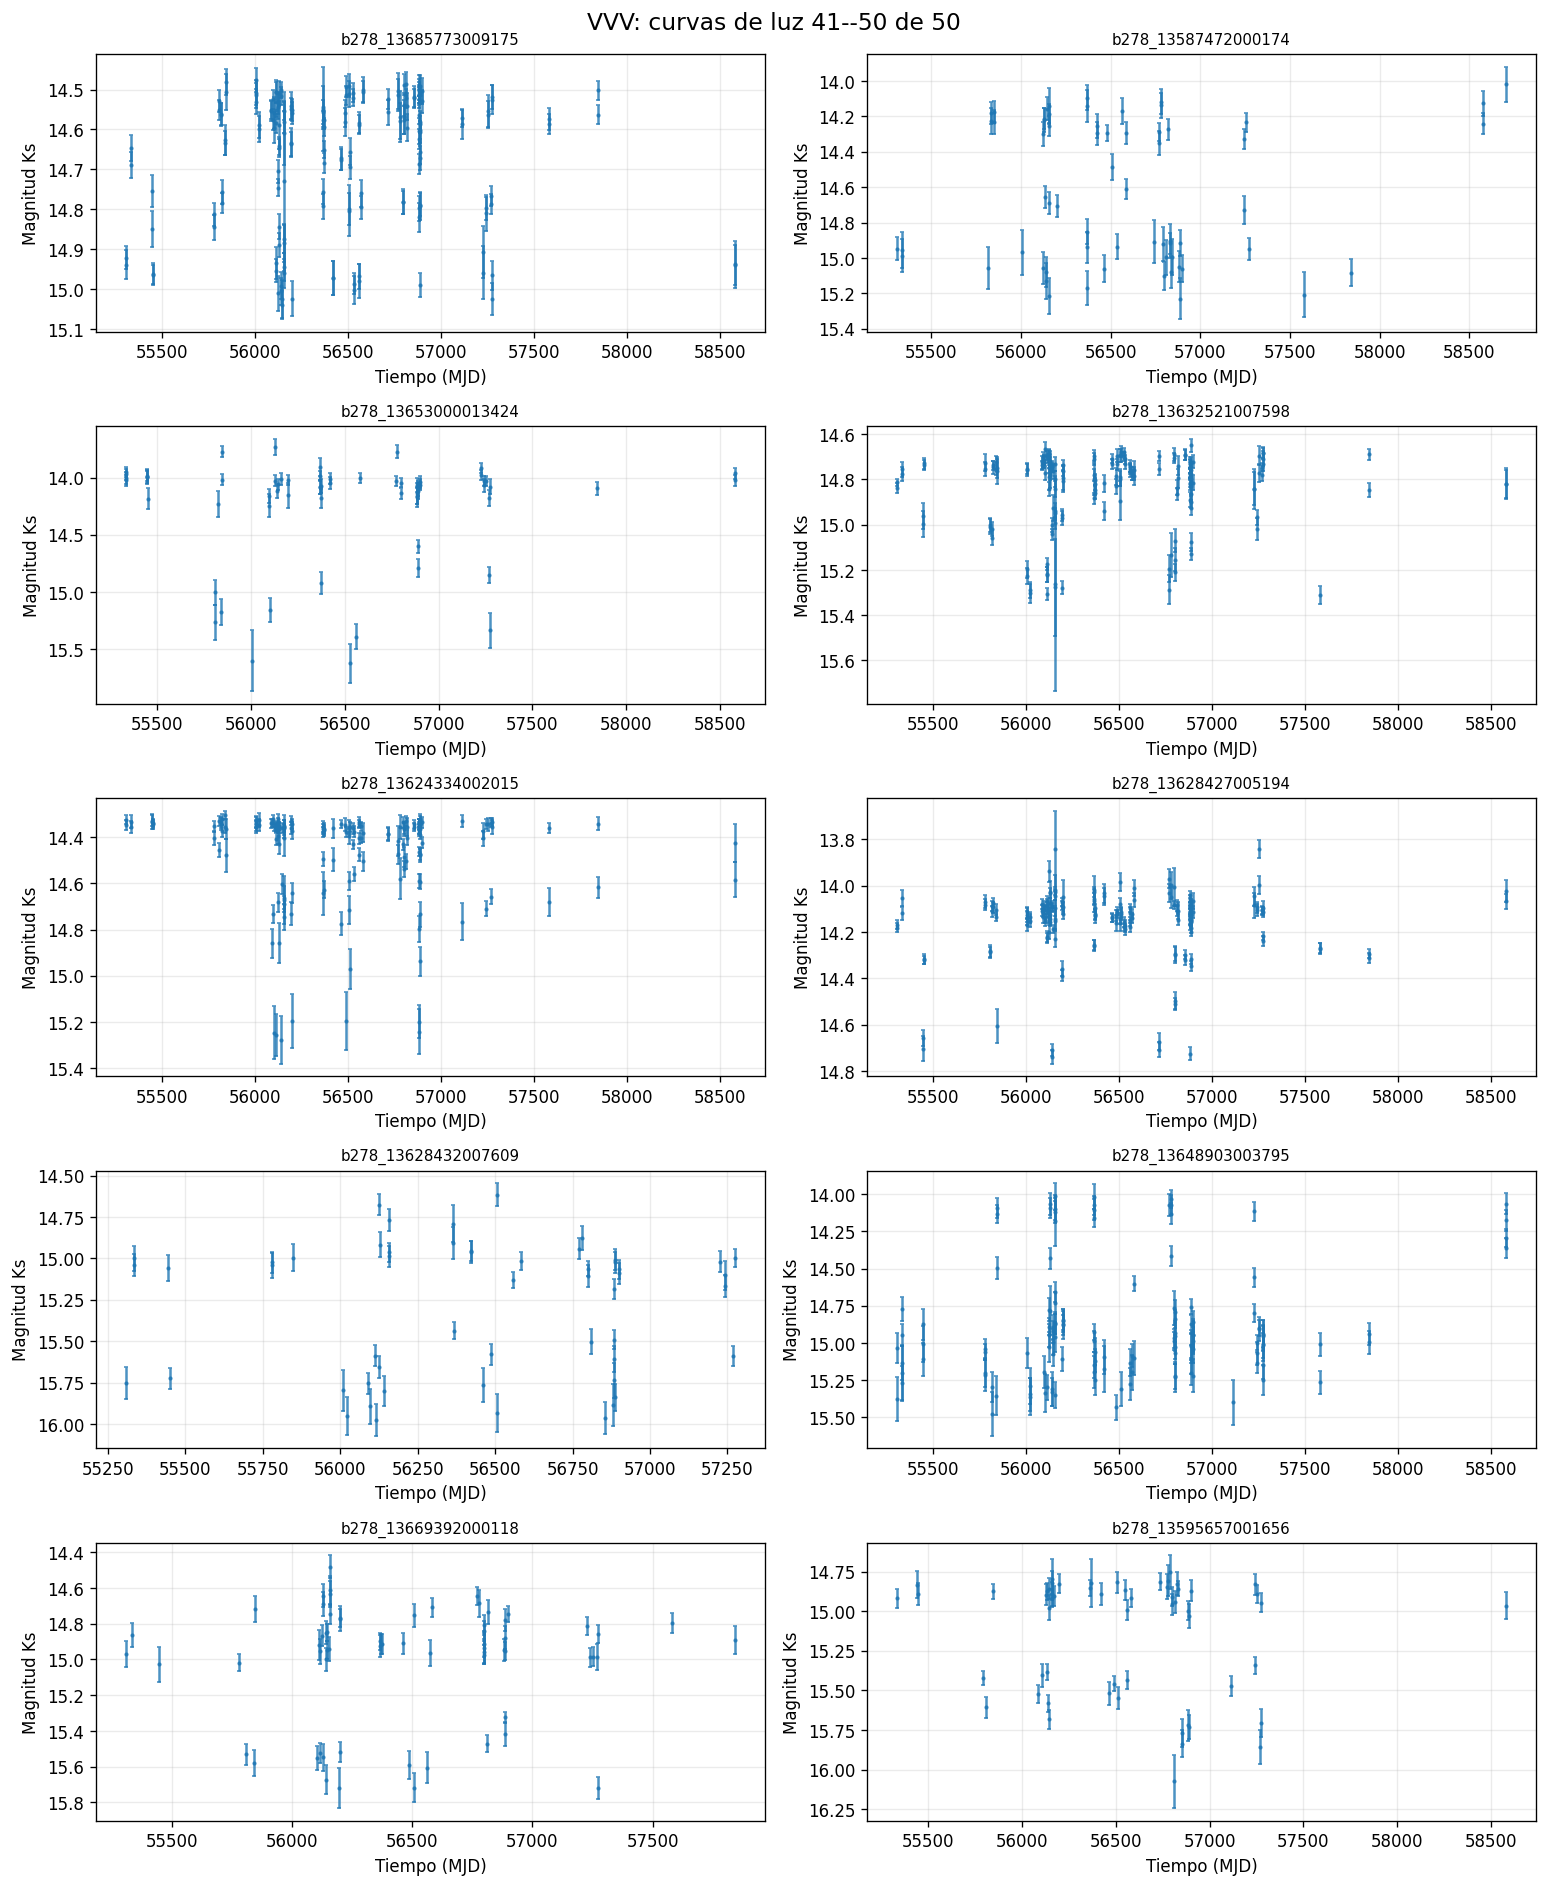

Páginas guardadas:
 - resultados_VVV_50_curvas\VVV_curvas_luz_pagina_01.png
 - resultados_VVV_50_curvas\VVV_curvas_luz_pagina_02.png
 - resultados_VVV_50_curvas\VVV_curvas_luz_pagina_03.png
 - resultados_VVV_50_curvas\VVV_curvas_luz_pagina_04.png
 - resultados_VVV_50_curvas\VVV_curvas_luz_pagina_05.png


In [7]:
# =========================
# FIGURAS POR PÁGINAS: 10 CURVAS POR PÁGINA
# =========================

page_paths = plot_lightcurve_pages(
    vvv_curves,
    outdir=OUTDIR,
    prefix="VVV",
    time_label=TIME_LABEL,
    mag_label=MAG_LABEL,
    per_page=10,
    ncols=2,
)

print("Páginas guardadas:")
for p in page_paths:
    print(" -", p)

In [8]:
# =========================
# 50 FIGURAS INDIVIDUALES: UNA POR ESTRELLA
# =========================

individual_dir = OUTDIR / "individuales"
individual_paths = []

for curve in vvv_curves:
    path = plot_single_lightcurve(
        curve,
        outdir=individual_dir,
        prefix="VVV",
        time_label=TIME_LABEL,
        mag_label=MAG_LABEL,
    )
    individual_paths.append(path)

print(f"Figuras individuales guardadas: {len(individual_paths)}")
print("Carpeta:", individual_dir)

Figuras individuales guardadas: 50
Carpeta: resultados_VVV_50_curvas\individuales
